<a href="https://colab.research.google.com/github/sougat23bai11043-code/Assignment-2/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-ML Assignment 2

## Customer Churn Prediction using Logistic Regression

Name: Sougat Das

Registration Number: 23BAI11043

Application Number: IN26010889

Batch Number: MPOnline - AI/ML Internship Batch 1(A) - Nishant Srivastava (1:00 pm-3:00 pm, Mon-Fri)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
import pandas as pd
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.select_dtypes(include=['int64','float64']).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [9]:
df.select_dtypes(include=['object']).columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [10]:
print("Target Variable : Churn")

Target Variable : Churn


In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_517/1099764709.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [13]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
            df[column] = le.fit_transform(df[column])

In [14]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
          y,
              test_size=0.20,
                  random_state=42
                  )

In [17]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [18]:
y_pred = model.predict(X_test)

y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

Accuracy Score : 0.8126330731014905


In [20]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 0.6687306501547987


In [21]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.579088471849866


In [22]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 0.6206896551724138


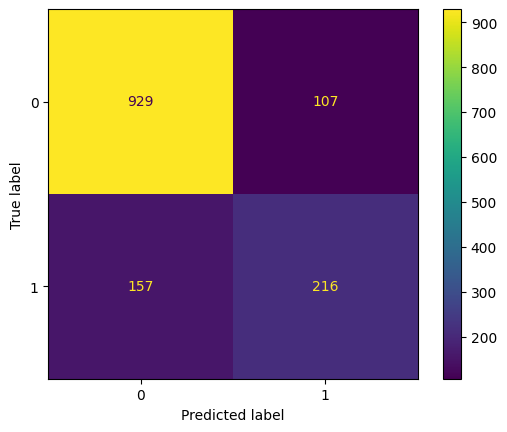

In [23]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

## Observations

1. Logistic Regression predicts customer churn with good accuracy.

2. The confusion matrix shows the number of correctly and incorrectly classified customers.

3. Accuracy, Precision, Recall, and F1 Score indicate satisfactory model performance.

## Conclusion

The Logistic Regression model was successfully developed to predict customer churn using demographic and service-related features. The dataset was preprocessed by handling missing values and encoding categorical variables. The model was evaluated using Accuracy, Precision, Recall, F1 Score, and the Confusion Matrix. The results indicate that Logistic Regression provides a reliable baseline for churn prediction. Factors such as contract type, tenure, monthly charges, and payment method can influence customer churn. However, Logistic Regression assumes a linear relationship between the features and the log-odds of the target variable, which may limit its ability to capture more complex patterns in customer behavior.